# What is My task?

The Intelligent team told me to develop a model that predicts whether patients have diabetes or not. They also offered me a dataset and told me to beware of this dataset. It's going to be fun.

# What I have?

I have a dataset with nearly 770 samples with these columns:

- **Pregnancies:** Number of times the patient has been pregnant.
- **Glucose:** Plasma glucose concentration 2 hours after an oral glucose test (mg/dL); **0 = missing data**.
- **BloodPressure:** Diastolic blood pressure (mm Hg); **0 = missing data**.
- **SkinThickness:** Triceps skin fold thickness measuring body fat (mm); **0 = missing data**.
- **Insulin:** 2-Hour serum insulin level (mu U/ml); **0 = missing data** (and the most frequently missing column).
- **BMI:** Body mass index (kg/m²); **0 = missing data**.
- **DiabetesPedigreeFunction:** Genetic risk score based on family history (float, 0 = no known family history).
- **Age:** Patient's age in years (integer).
- **Outcome:** Target variable; **0 = no diabetes**, **1 = diabetes** diagnosed.

> **Note**: Some columns in this dataset has null value and Intelligent this warned me about this.

# What are metrics?

They told me to use accuracy and F1 score.

# Hands on code

## Import Libraries

We are allowed to use these libraries:

In [387]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from typing import Literal
import joblib
import helpers

SEED = 231

## Data Part

### Load Dataset

In [388]:
df = pd.read_csv("./diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [389]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Ok datatypes in this dataset seems to be ok. But in this dataset null values set as **0**! 

If you don't belive in me just ask yourself, How can a random guy survive with zero `BloodPressure`? 

### Analyze numerical features

Our only categorical feature is the target feature `Outcome` which only has value 0 or 1. Rest of them is numerical so let's get them:

In [390]:
df_num = df.drop(columns=["Outcome"])

Let's see a histogram from data:

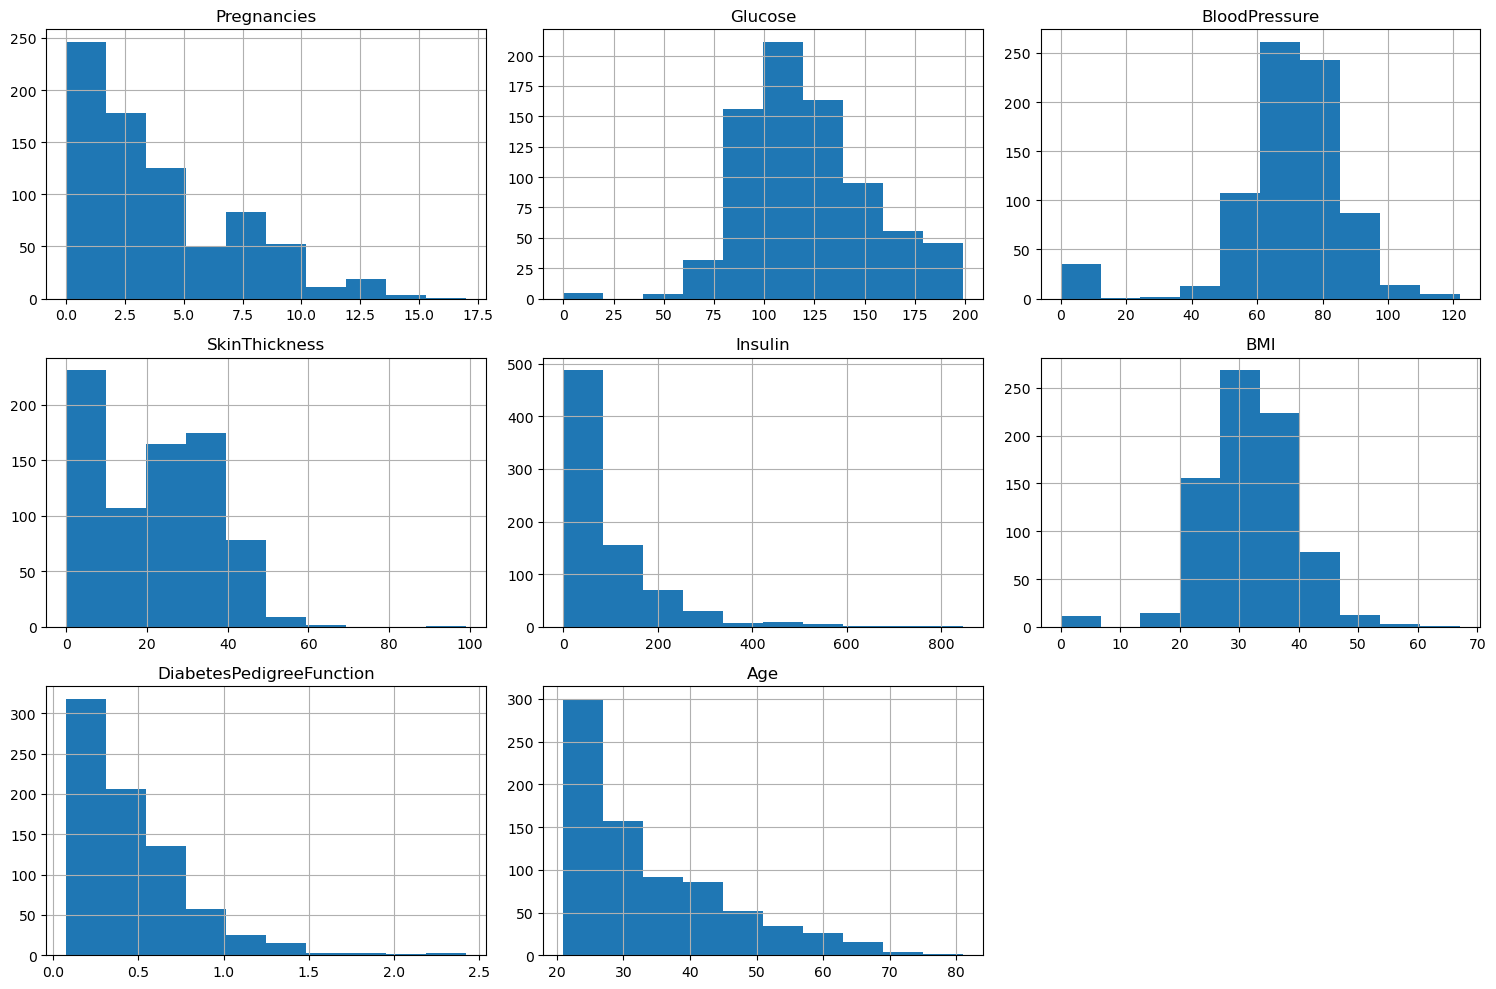

In [391]:
df_num.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

As we can see features `Glucose`, `BloodPressure`, `SkinThickness` and `BMI` are normaly distributed. While `DiabetesPedigreeFunction` and `Age` has high skew to right.

Now let's check the boxplot:

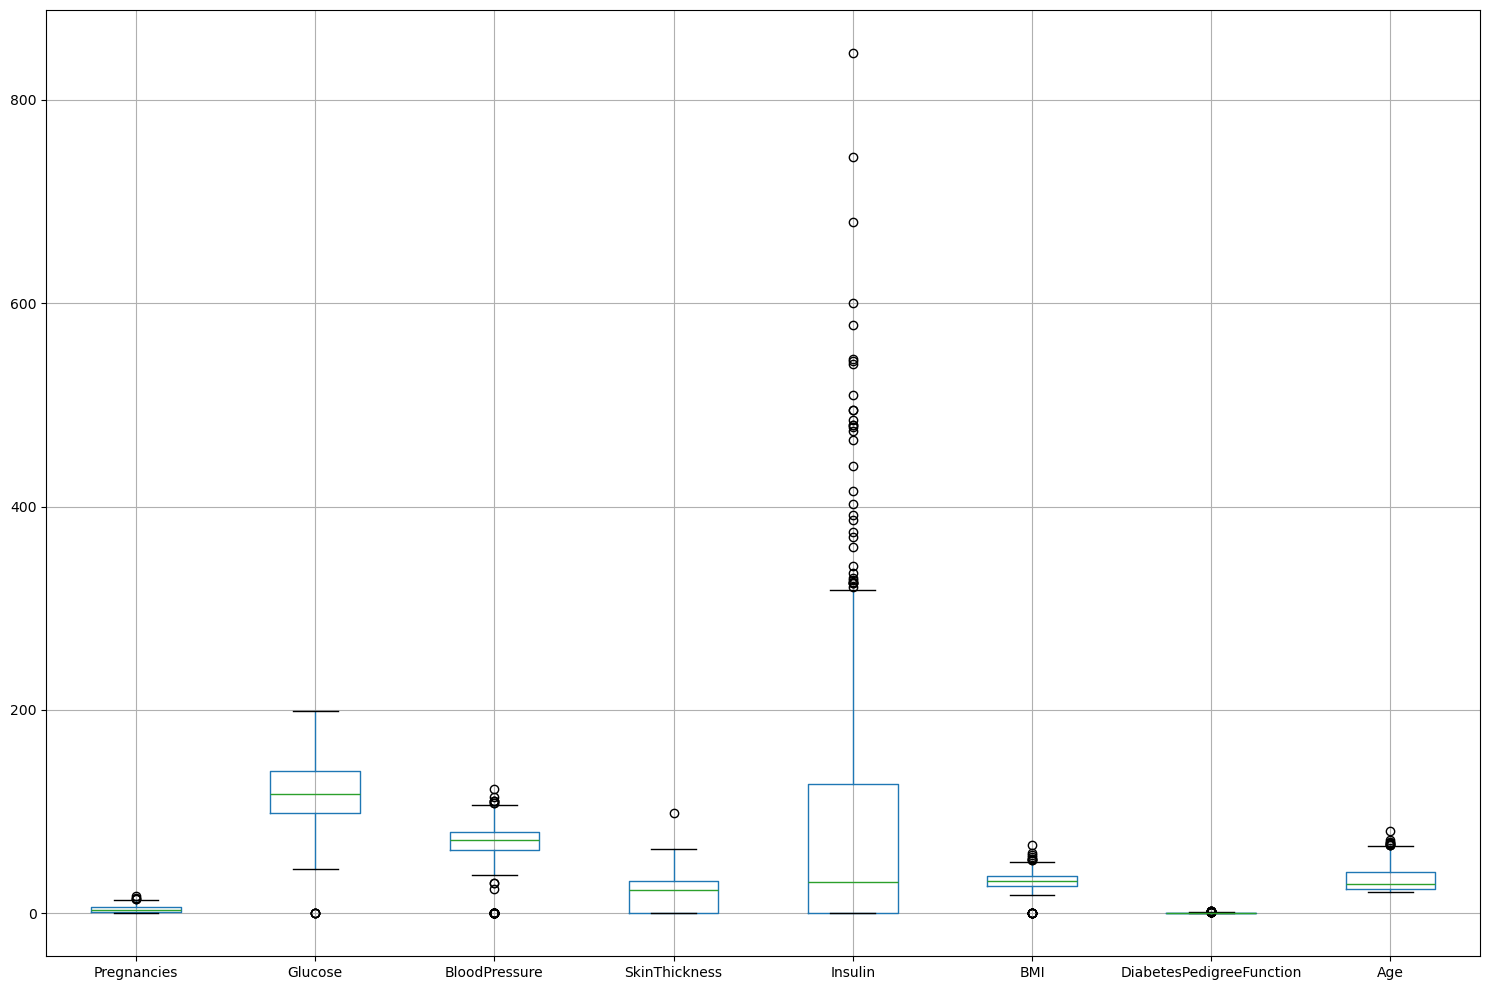

In [392]:
df_num.boxplot(figsize=(15, 10))
plt.tight_layout()
plt.show()

Seems like feature `Insulin` has a lot of outliers.

For final part let's check some statistical stuff:

In [393]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


This describe show again that feature `Insulin` has outliers a lot.

### Analyze categorical features

Our only categorical feature is the target feature `Outcome` which only has value 0 or 1.

Let's check is this data balanced?

<Axes: >

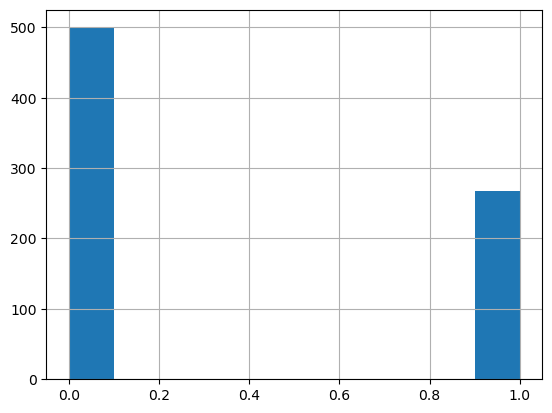

In [394]:
df["Outcome"].hist()

Well absolutly not, data with value 1 is nearly half of data with value 0. Which means that it is easy for model to predict 0! I must balance it.

### Check Correlation

<Axes: >

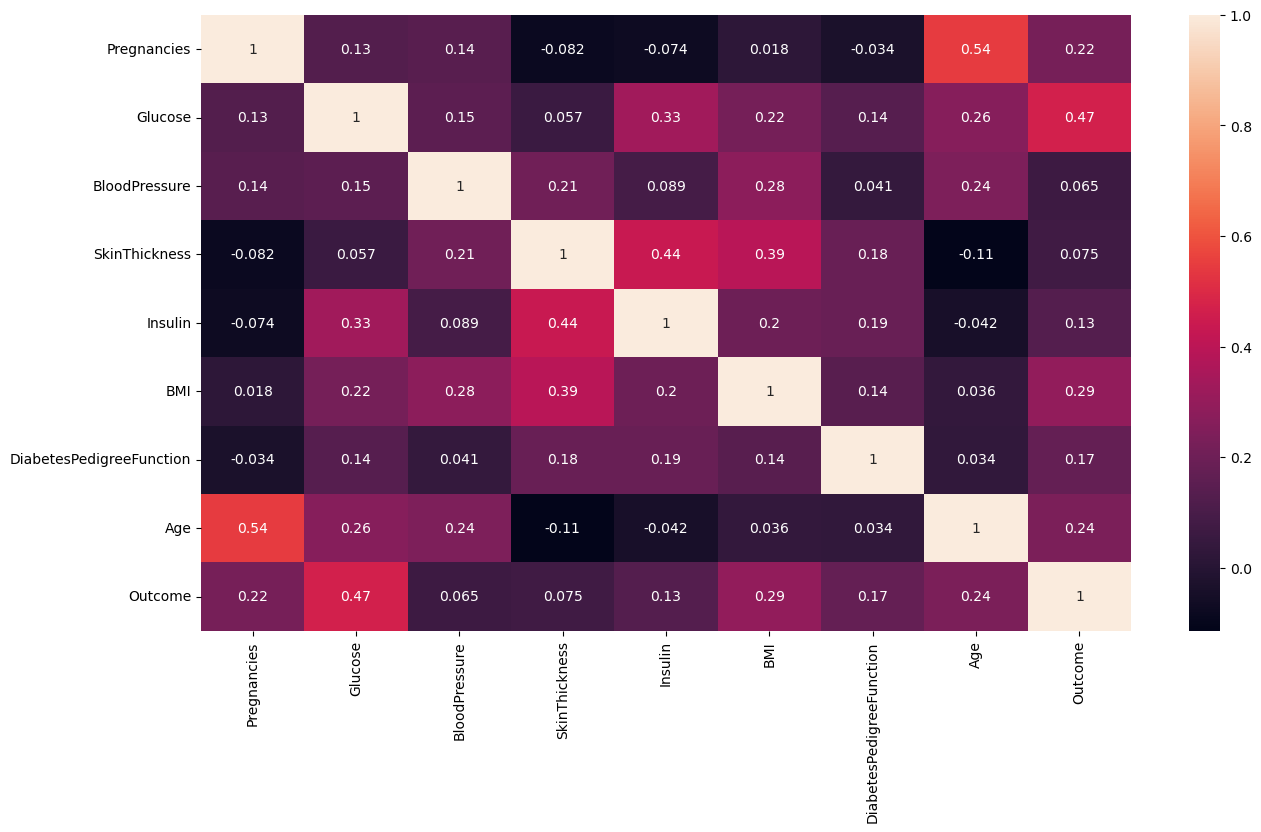

In [395]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True)

The data correlations look fine. The highest correlation is between the features `Age` and `Pregnancies`, with a value of 54%.

## Preprocess

### Missed Values

As you know in most of these features, value 0 means null so let's turn these features 0 to `np.nan`.

In [396]:
missed_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "BMI",
]

for col in missed_cols:
    df[col] = df[col].replace(to_replace=0, value=np.nan)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


Now we can see missed values:

In [397]:
df.isna().sum() / np.abs(df.isna().sum() - 768) * 100

Pregnancies                  0.000000
Glucose                      0.655308
BloodPressure                4.774898
SkinThickness               41.959335
Insulin                      0.000000
BMI                          1.453104
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

As we can see feature `SkinThickness` has highest missed values with 42% value missed, So for this one it is better to use **KNN imputer**. But for the rest we can simply use **mean** of **median**.

So let's set a column transformer for this task:

In [398]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [399]:
men_missed_value_cols = ["Glucose", "BloodPressure", "BMI"]
knn_missed_value_col = "SkinThickness"

men_missed_value_index = [1, 2, 5]
knn_missed_value_index = 3

preprocessor = ColumnTransformer(
    transformers=[
        (
            "mean_imputer",
            SimpleImputer(strategy="mean", add_indicator=False, missing_values=np.nan),
            men_missed_value_index,
        ),
        (
            "knn_imputer",
            KNNImputer(n_neighbors=5, missing_values=np.nan),
            [knn_missed_value_index],
        ),  # ONLY this column is passed to KNN
    ],
    remainder="passthrough",
)

### Handel Outliers and scale data

As you remember we had so many outliers, And it is better to scale datas. So I want to use robust scalar for this:

In [400]:
robust_scaler = RobustScaler()

### Handel imbalanced data

This dataset has a improtant balance issuse, We can fix it by oversampling class 1. And I'll use `SMOTE` algorithm for oversampling:

In [401]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

smote = SMOTE(random_state=SEED)

Now see the result:

### Train Test split

In [402]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=SEED
)

### Apply preprocess objects

We created 2 objects, one of them was for handeling missed data and one of them was for handeling imbalance data.

Let's apply them to the data:

In [403]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [404]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [405]:
X_train = robust_scaler.fit_transform(X_train)
X_test = robust_scaler.transform(X_test)

## Model Design

The Intelligent team told me to use `logistic regression` and `random forest`, I'll use some other algorithms too.

### Logistic Regression

In [406]:
lg = LogisticRegression(random_state=SEED)
lg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,231
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [407]:
y_pred = lg.predict(X_test)
lg_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="LogisticRegression"
)

print(
    f"\nThe F1-score of {lg_results.model_name} is {lg_results.f1_score} and Accuracy is {lg_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        57
           1       0.56      0.75      0.64        20

    accuracy                           0.78        77
   macro avg       0.73      0.77      0.74        77
weighted avg       0.81      0.78      0.79        77


The F1-score of LogisticRegression is 63.829787234042556 and Accuracy is 77.92207792207793


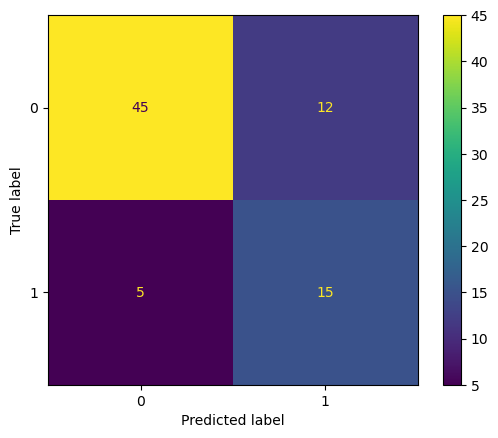

In [408]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

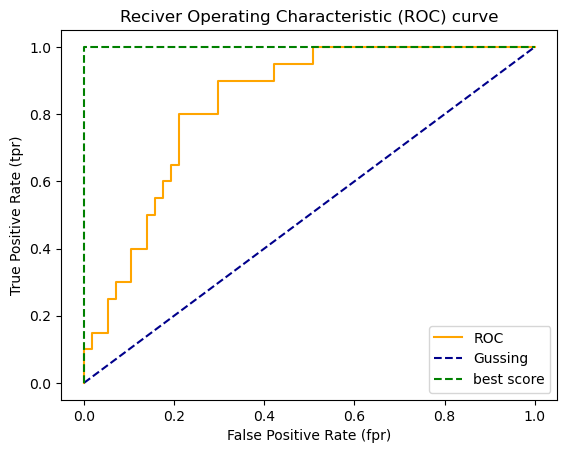

In [409]:
helpers.plot_roc_curve(model=lg, X_test=X_test, y_test=y_test)

#### Logistic Regression WIth GridSearch

In [410]:
lg_grid = LogisticRegression()

param_grid_lg = {
    "C": [0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "max_iter": [100, 150, 200],
}

lg_grid = helpers.run_grid_search(
    model=lg_grid,
    param_grid=param_grid_lg,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="LogisticRegression with gridsearch",
)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

--- Grid Search for `LogisticRegression with gridsearch` ---
Best Hyper Parameters: {'C': 0.1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}
Best Mean Log Loss (CV): 0.5011


In [411]:
y_pred = lg_grid.predict(X_test)

lg_grid_results = helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression with gridsearch"
)

print(
    f"\nThe F1-score of {lg_grid_results.model_name} is {lg_grid_results.f1_score} and Accuracy is {lg_grid_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.87      0.79      0.83        57
           1       0.52      0.65      0.58        20

    accuracy                           0.75        77
   macro avg       0.69      0.72      0.70        77
weighted avg       0.78      0.75      0.76        77


The F1-score of LogisticRegression with gridsearch is 57.77777777777777 and Accuracy is 75.32467532467533


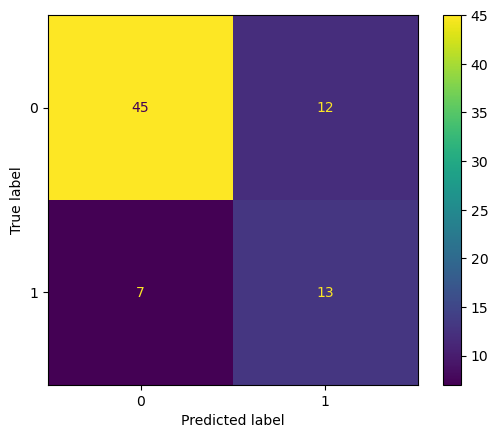

In [412]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

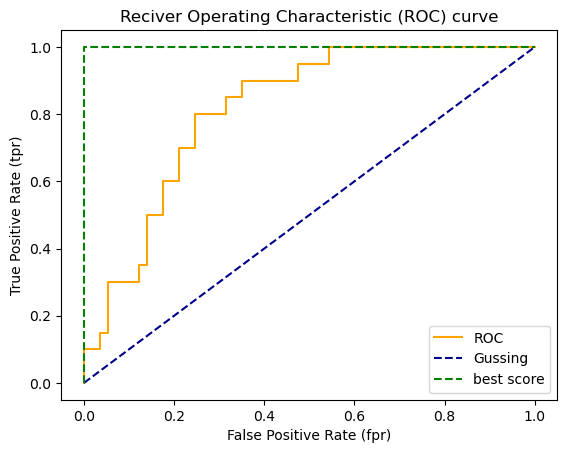

In [413]:
helpers.plot_roc_curve(model=lg_grid, X_test=X_test, y_test=y_test)

### Random Forest

In [414]:
rfc = RandomForestClassifier(n_estimators=85, random_state=SEED)
rfc.fit(X_train, y_train)

,n_estimators,85
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [415]:
y_pred = rfc.predict(X_test)
rfc_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="RandomForestClassifier"
)

print(
    f"\nThe F1-score of {rfc_results.model_name} is {rfc_results.f1_score} and Accuracy is {rfc_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.86      0.77      0.81        57
           1       0.50      0.65      0.57        20

    accuracy                           0.74        77
   macro avg       0.68      0.71      0.69        77
weighted avg       0.77      0.74      0.75        77


The F1-score of RandomForestClassifier is 56.52173913043478 and Accuracy is 74.02597402597402


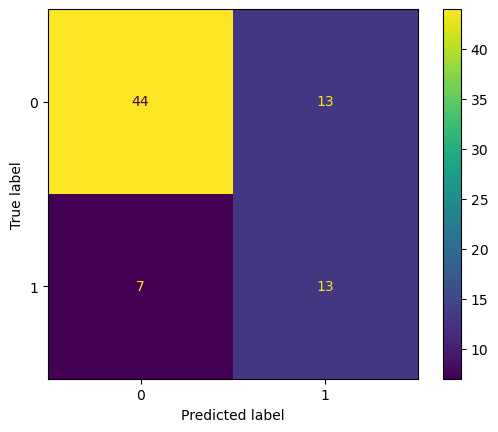

In [416]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

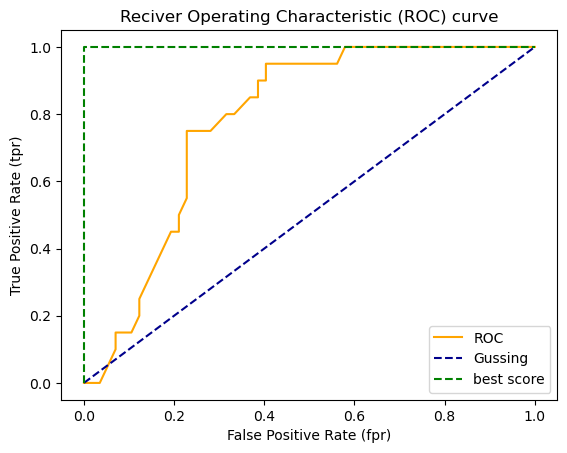

In [417]:
helpers.plot_roc_curve(model=rfc, X_test=X_test, y_test=y_test)

#### Random Forest With GridSearch

In [418]:
rfc_grid = RandomForestClassifier(random_state=SEED)

param_grid_rf = {
    "n_estimators": [80, 140],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rfc_grid = helpers.run_grid_search(
    model=rfc_grid,
    param_grid=param_grid_rf,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="RandomForestClassifier with gridsearch",
)

Fitting 3 folds for each of 108 candidates, totalling 324 fits

--- Grid Search for `RandomForestClassifier with gridsearch` ---
Best Hyper Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 140}
Best Mean Log Loss (CV): 0.4221


In [419]:
y_pred = rfc_grid.predict(X_test)
rfc_grid_results = helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="RandomForestClassifier with gridsearch"
)

print(
    f"\nThe F1-score of {rfc_grid_results.model_name} is {rfc_grid_results.f1_score} and Accuracy is {rfc_grid_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.86      0.77      0.81        57
           1       0.50      0.65      0.57        20

    accuracy                           0.74        77
   macro avg       0.68      0.71      0.69        77
weighted avg       0.77      0.74      0.75        77


The F1-score of RandomForestClassifier with gridsearch is 56.52173913043478 and Accuracy is 74.02597402597402


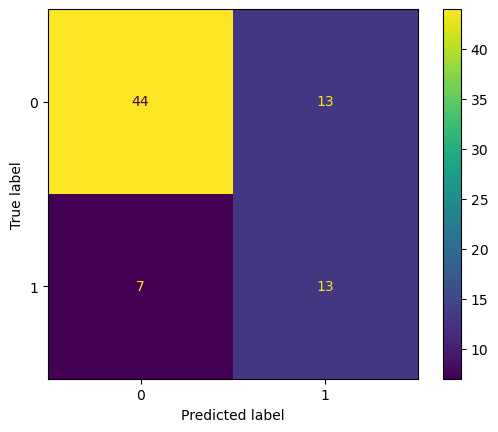

In [420]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

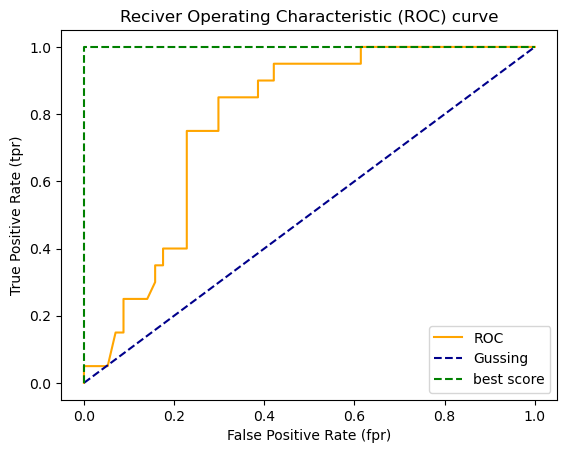

In [421]:
helpers.plot_roc_curve(model=rfc_grid, X_test=X_test, y_test=y_test)

### SVC

In [422]:
svc = SVC(random_state=SEED, probability=True)
svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [423]:
y_pred = svc.predict(X_test)

svc_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="SVC"
)

print(
    f"\nThe F1-score of {svc_results.model_name} is {svc_results.f1_score} and Accuracy is {svc_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.90      0.77      0.83        57
           1       0.54      0.75      0.62        20

    accuracy                           0.77        77
   macro avg       0.72      0.76      0.73        77
weighted avg       0.80      0.77      0.78        77


The F1-score of SVC is 62.5 and Accuracy is 76.62337662337663


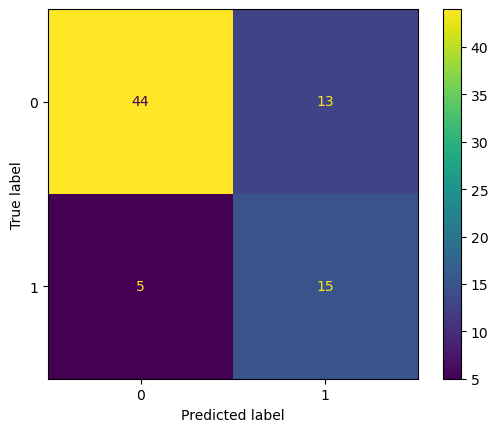

In [424]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

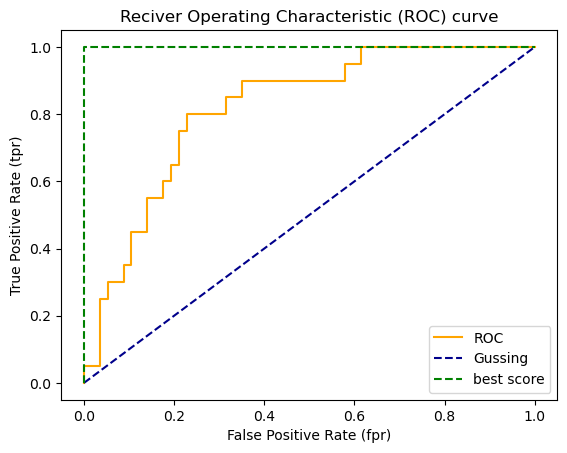

In [425]:
helpers.plot_roc_curve(model=svc, X_test=X_test, y_test=y_test)

#### SVC With GridSearch

In [426]:
svc_grid = SVC(random_state=SEED, probability=True)

param_grid_svc = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"],
}

svc_grid = helpers.run_grid_search(
    model=svc_grid,
    param_grid=param_grid_svc,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="SVC with gridsearch",
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- Grid Search for `SVC with gridsearch` ---
Best Hyper Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best Mean Log Loss (CV): 0.4619


In [427]:
y_pred = svc_grid.predict(X_test)
svc_grid_results = helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="SVC with gridsearch"
)

print(
    f"\nThe F1-score of {svc_grid_results.model_name} is {svc_grid_results.f1_score} and Accuracy is {svc_grid_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        57
           1       0.48      0.65      0.55        20

    accuracy                           0.73        77
   macro avg       0.67      0.70      0.68        77
weighted avg       0.76      0.73      0.74        77


The F1-score of SVC with gridsearch is 55.319148936170215 and Accuracy is 72.72727272727273


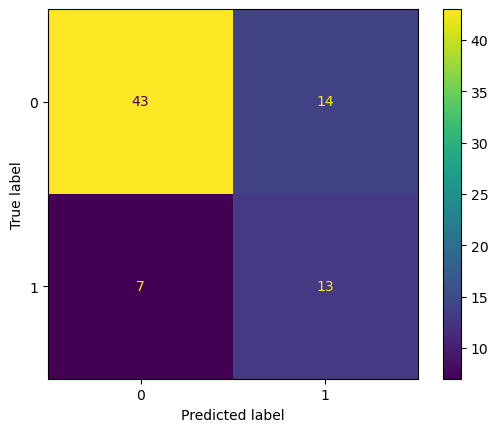

In [428]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

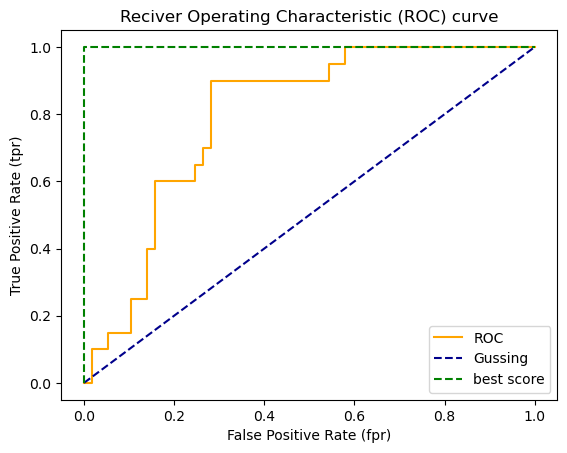

In [429]:
helpers.plot_roc_curve(model=svc_grid, X_test=X_test, y_test=y_test)

### KNN classifier

In [430]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [431]:
y_pred = knn.predict(X_test)

knn_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="KNeighborsClassifier"
)

print(
    f"\nThe F1-score of {knn_results.model_name} is {knn_results.f1_score} and Accuracy is {knn_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.88      0.77      0.82        57
           1       0.52      0.70      0.60        20

    accuracy                           0.75        77
   macro avg       0.70      0.74      0.71        77
weighted avg       0.79      0.75      0.76        77


The F1-score of KNeighborsClassifier is 59.57446808510638 and Accuracy is 75.32467532467533


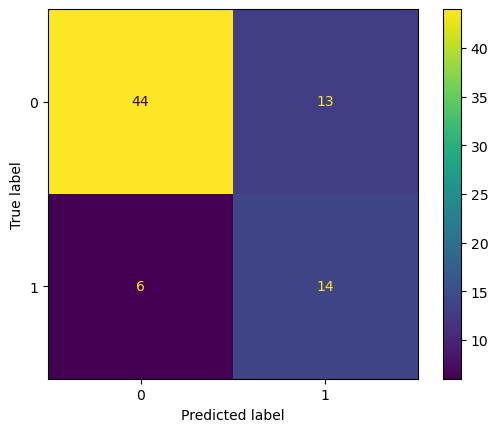

In [432]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

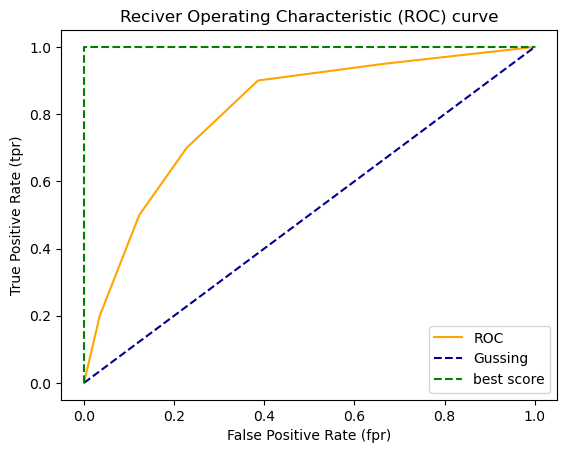

In [433]:
helpers.plot_roc_curve(model=knn, X_test=X_test, y_test=y_test)

#### KNNClassifier With GridSearch

In [434]:
knn_grid = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2],  # only used when metric='minkowski'
}

knn_grid = helpers.run_grid_search(
    model=knn_grid,
    param_grid=param_grid_knn,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="KNN with gridsearch",
)

Fitting 3 folds for each of 60 candidates, totalling 180 fits

--- Grid Search for `KNN with gridsearch` ---
Best Hyper Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Best Mean Log Loss (CV): 0.7518


In [435]:
y_pred = knn_grid.predict(X_test)

knn_grid_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="KNN with gridsearch"
)

print(
    f"\nThe F1-score of {knn_grid_results.model_name} is {knn_grid_results.f1_score} and Accuracy is {knn_grid_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        57
           1       0.55      0.80      0.65        20

    accuracy                           0.78        77
   macro avg       0.73      0.79      0.75        77
weighted avg       0.82      0.78      0.79        77


The F1-score of KNN with gridsearch is 65.3061224489796 and Accuracy is 77.92207792207793


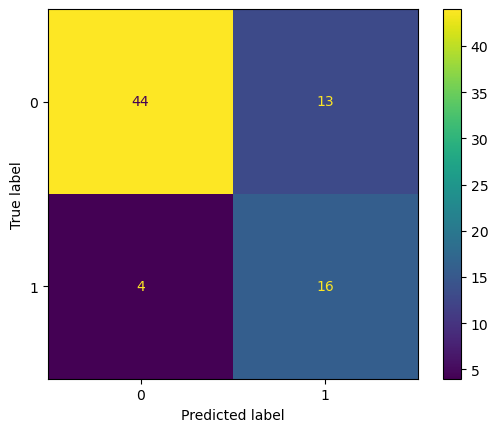

In [436]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

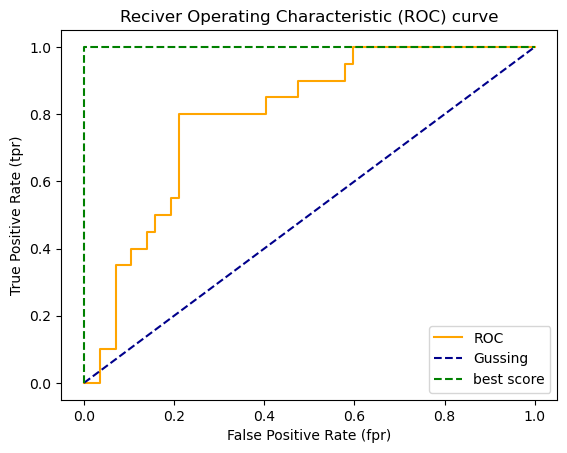

In [437]:
helpers.plot_roc_curve(model=knn_grid, X_test=X_test, y_test=y_test)

### Decision Tree

In [438]:
tree = DecisionTreeClassifier(random_state=SEED, max_depth=5)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,231
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [439]:
y_pred = tree.predict(X_test)

tree_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="decisionTree"
)

print(
    f"\nThe F1-score of {tree_results.model_name} is {tree_results.f1_score} and Accuracy is {tree_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        57
           1       0.48      0.65      0.55        20

    accuracy                           0.73        77
   macro avg       0.67      0.70      0.68        77
weighted avg       0.76      0.73      0.74        77


The F1-score of decisionTree is 55.319148936170215 and Accuracy is 72.72727272727273


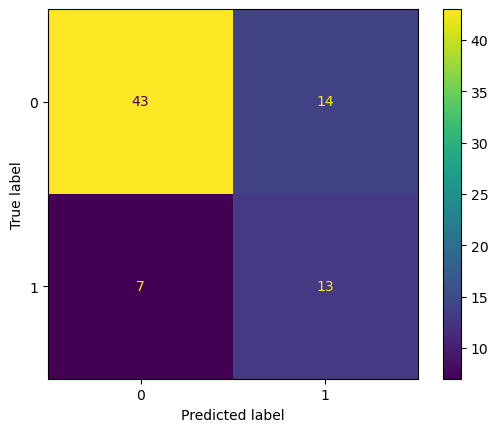

In [440]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

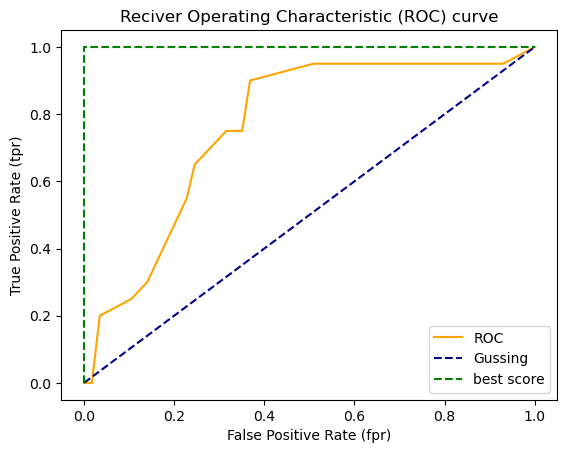

In [441]:
helpers.plot_roc_curve(model=tree, X_test=X_test, y_test=y_test)

#### DecisionTree With GridSearch

In [442]:
tree_grid = DecisionTreeClassifier(random_state=SEED)

param_grid_dt = {
    "criterion": ["gini", "entropy"],  # splitting quality
    "max_depth": [3, 5, 10, 20, None],  # None = fully grown
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 10],
    "max_features": ["sqrt", "log2", None],  # None = all features
}

tree_grid = helpers.run_grid_search(
    model=tree_grid,
    param_grid=param_grid_dt,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="Decision Tree with gridsearch",
)

Fitting 3 folds for each of 480 candidates, totalling 1440 fits

--- Grid Search for `Decision Tree with gridsearch` ---
Best Hyper Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Mean Log Loss (CV): 0.5322


In [443]:
y_pred = tree_grid.predict(X_test)

tree_grid_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="Decision Tree with gridsearch"
)

print(
    f"\nThe F1-score of {tree_grid_results.model_name} is {tree_grid_results.f1_score} and Accuracy is {tree_grid_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.90      0.63      0.74        57
           1       0.43      0.80      0.56        20

    accuracy                           0.68        77
   macro avg       0.67      0.72      0.65        77
weighted avg       0.78      0.68      0.70        77


The F1-score of Decision Tree with gridsearch is 56.14035087719298 and Accuracy is 67.53246753246754


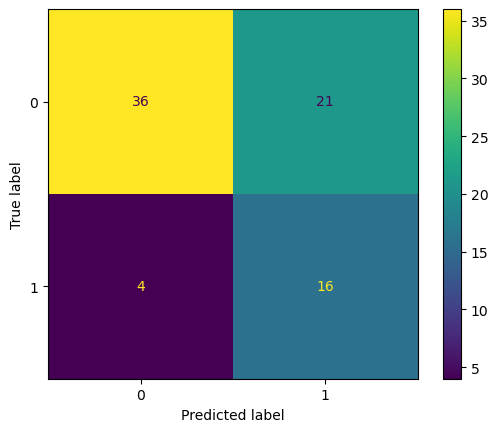

In [444]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

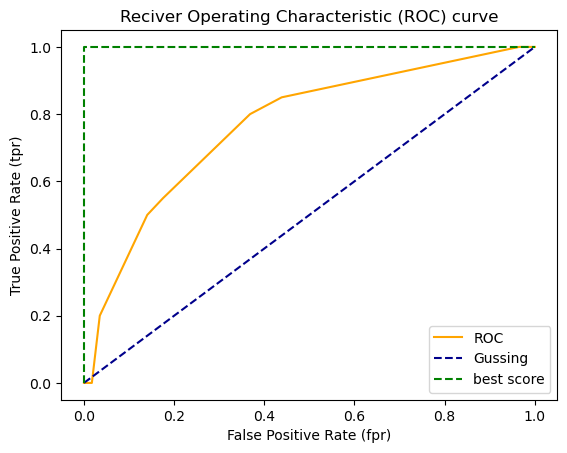

In [445]:
helpers.plot_roc_curve(model=tree_grid, X_test=X_test, y_test=y_test)

### Find best model

Let's define a function which will search list of models results and find the best one:

In [446]:
def find_best_model(
    models_result: list,
    metric: Literal["accuracy", "recall", "precision", "f1_score", "MSE", "MAE"],
    higher_is_better: bool = True,
):
    if not models_result:
        return None

    if higher_is_better:
        return max(models_result, key=lambda m: getattr(m, metric))
    else:
        return min(models_result, key=lambda m: getattr(m, metric))

In [447]:
models_result = [
    lg_results,
    lg_grid_results,
    svc_results,
    svc_grid_results,
    rfc_results,
    rfc_grid_results,
    knn_results,
    knn_grid_results,
    tree_results,
    tree_grid_results,
]
best_model_result = find_best_model(models_result=models_result, metric="f1_score")

print(
    f"The best model is {best_model_result.model_name} with accuracy {best_model_result.accuracy} and F1 {best_model_result.f1_score}"
)

The best model is KNN with gridsearch with accuracy 77.92207792207793 and F1 65.3061224489796


So the best results is for `KNN with gridsearch` algorithm. Time ro setup the pipline:

In [448]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", robust_scaler),
        ("classifier", knn_grid),
    ]
)

Pipeline is ready time to fit on it:

In [449]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mean_imputer', ...), ('knn_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


And evaluate it:

In [454]:
y_pred = pipeline.predict(X_test)
pipeline_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="pipeline"
)

print(
    f"\nThe F1-score of {pipeline_results.model_name} is {pipeline_results.f1_score} and Accuracy is {pipeline_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        57
           1       0.55      0.80      0.65        20

    accuracy                           0.78        77
   macro avg       0.73      0.79      0.75        77
weighted avg       0.82      0.78      0.79        77


The F1-score of pipeline is 65.3061224489796 and Accuracy is 77.92207792207793


## Save pipline (joblib)

We save model using joblib like this:

In [451]:
MODEL_NAME = "diabet-analysis.joblib"

joblib.dump(pipeline, MODEL_NAME)

['diabet-analysis.joblib']

It worked, Now i want to load it and test it:

In [455]:
pipline_loaded: Pipeline = joblib.load(MODEL_NAME)

y_pred = pipline_loaded.predict(X_test)
pipline_loaded_results = helpers.evaluate_classification_model(
    y_pred=y_pred, y_test=y_test, model_name="Loaded pipeline"
)

print(
    f"\nThe F1-score of {pipline_loaded_results.model_name} is {pipline_loaded_results.f1_score} and Accuracy is {pipline_loaded_results.accuracy}"
)

              precision    recall  f1-score   support

           0       0.92      0.77      0.84        57
           1       0.55      0.80      0.65        20

    accuracy                           0.78        77
   macro avg       0.73      0.79      0.75        77
weighted avg       0.82      0.78      0.79        77


The F1-score of Loaded pipeline is 65.3061224489796 and Accuracy is 77.92207792207793


It is completly same as original model.